# LLMs and augmentations

Workflows and agentic systems are based on LLMs and the various augmentations you add to them. Tool calling, structured outputs, and short term memory are a few options for tailoring LLMs to your needs.

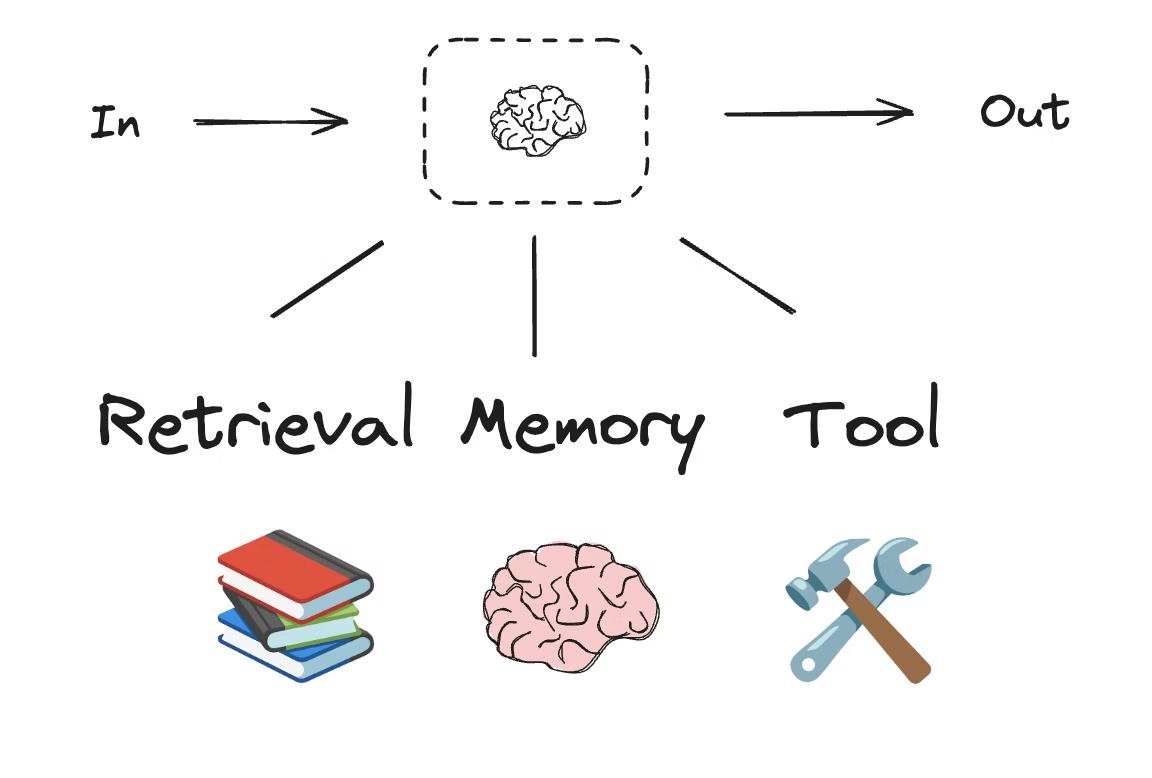


In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["ANTHROPIC_API_KEY"] = os.getenv("ANTHROPIC_API_KEY")

In [ ]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("claude-haiku-4-5", temperature=0, max_tokens=100)

from typing import List
from pydantic import BaseModel, Field
import logging

logging.basicConfig(level=logging.INFO)


# -------------------------------
# Structured Output Schema
# -------------------------------


class SearchQuery(BaseModel):
    search_query: str = Field(description="Optimized search query for web lookup")
    justification: str = Field(
        description="Reason why this query helps answer the user question"
    )


# -------------------------------
# Tool Definition
# -------------------------------


def multiply(a: int, b: int) -> int:
    """Multiply two numbers."""
    logging.info(f"Multiplying {a} * {b}")
    return a * b


# -------------------------------
# Augment LLM
# -------------------------------

structured_llm = llm.with_structured_output(SearchQuery)

llm_with_tools = llm.bind_tools([multiply])


# -------------------------------
# Structured Output Invocation
# -------------------------------


def generate_search_query(question: str) -> SearchQuery:
    """Generate structured search query."""
    result = structured_llm.invoke(question)
    logging.info(result)
    return result


# -------------------------------
# Tool Invocation Example
# -------------------------------


def run_tool_agent(question: str):
    msg = llm_with_tools.invoke(question)
    return msg.tool_calls

In [7]:
query = generate_search_query("How does Calcium CT score relate to cholesterol?")

print(query.search_query)
print(query.justification)

INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
INFO:root:search_query='Calcium CT score relationship to cholesterol' justification='To find information about how Coronary Artery Calcium (CAC) CT score relates to cholesterol levels and cardiovascular risk'


Calcium CT score relationship to cholesterol
To find information about how Coronary Artery Calcium (CAC) CT score relates to cholesterol levels and cardiovascular risk


In [8]:
tool_calls = run_tool_agent("What is 2 times 3?")
print(tool_calls)

INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'toolu_01RyJBPKdbEprDNmJ3iCvugA', 'type': 'tool_call'}]


# Core LLM Augmentations

| Augmentation | Purpose | Example |
|---|---|---|
| Structured Output | Produce predictable machine-readable responses | JSON schema using Pydantic |
| Tool Calling | Allow LLM to execute functions/APIs | Calculator, web search |
| Short-term Memory | Track conversation context during session | Chat history |
| Long-term Memory | Persist user data across sessions | User preferences |
| Retrieval (RAG) | Access external knowledge | Vector DB search |
| Workflow Orchestration | Multi-step reasoning execution | Graph-based workflows |
| Planning / Task Decomposition | Break complex tasks into steps | Plan → Execute |
| Guardrails / Validation | Enforce correctness and safety | Output validators |
| Human-in-the-loop | Human approval before actions | Approve sending email |
| Streaming Responses | Real-time response generation | Token streaming |
| Multi-Agent Collaboration | Multiple agents working together | Planner + Executor |
| Tool Result Memory | Store tool outputs for reuse | Cached tool results |
| Prompt Templates | Standardize prompts | Reusable prompt formats |
| Self-Reflection / Critique | Model evaluates its own output | Self-check loop |
| Caching | Reduce latency and cost | Response cache |
| Monitoring & Observability | Track performance and errors | Logging and tracing |
| Evaluation Frameworks | Measure model quality | Automated tests |
| Model Routing | Dynamically select best model | Cheap vs powerful model |

# Production LLM Augmentation Stack

| Component | Role in System | Example Implementation |
|---|---|---|
| LLM | Core reasoning engine | GPT, Claude, Mistral |
| Prompt Templates | Standardize prompts sent to model | PromptTemplate |
| Structured Output | Enforce predictable response schema | Pydantic output parser |
| Tool Calling | Enable external actions | API calls, Python functions |
| Retrieval (RAG) | Provide external knowledge context | Vector database retrieval |
| Memory | Maintain conversation or user state | Chat memory |
| Guardrails | Validate and constrain outputs | Output validation |
| Workflow Graph | Multi-step agent orchestration | LangGraph nodes/edges |
| Observability | Monitor system behavior | Logging, tracing |
| Evaluation | Measure system performance | Test datasets |
| Caching | Reduce latency and cost | Response cache |
| Model Routing | Select best model dynamically | Router chains |

# Layered LLM Architecture

| Layer | Augmentation | Purpose |
|---|---|---|
| Input Layer | Prompt Templates | Format user input for the model |
| Context Layer | Retrieval (RAG) | Inject external knowledge |
| Memory Layer | Short-term + Long-term Memory | Maintain conversation state |
| Reasoning Layer | Planning / Decomposition | Break complex tasks into steps |
| Output Layer | Structured Output | Generate machine-readable responses |
| Action Layer | Tool Calling | Execute functions or APIs |
| Control Layer | Guardrails / Validation | Ensure safe and correct output |
| Execution Layer | Workflow Orchestration | Manage multi-step agent flows |
| Optimization Layer | Caching / Model Routing | Improve performance and cost |
| Evaluation Layer | Monitoring / Observability / Testing | Track system reliability |

Core Augmentations (feature catalog)

        ↓

Production Stack (real-world system components)

        ↓
        
Layered Architecture (system design structure)